## Dataset Overview
The dataset contains multiple texture classes (e.g., aluminium_foil, brown_bread, corduroy, etc.). Each class directory contains `train` and `test` folders with PNG images captured under varying scales, lighting conditions, and viewpoints. The notebook keeps all paths relative to this repository so it can be re-run without modification.


In [ ]:
from __future__ import annotations
import json
import math
import random
from pathlib import Path
from typing import Dict, List

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm.auto import tqdm
from itertools import combinations

from skimage import color, feature, filters, io
from skimage.util import img_as_float32
from skimage.feature import graycomatrix, graycoprops
from sklearn.cluster import (AgglomerativeClustering, DBSCAN, KMeans, MeanShift, estimate_bandwidth)
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.model_selection import ParameterGrid
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

plt.style.use('seaborn-v0_8')

DATA_ROOT = Path('.').resolve()
CLASS_FOLDERS = sorted([
    p for p in DATA_ROOT.iterdir()
    if p.is_dir() and (p / 'train').exists()
])
RAW_FEATURES_PATH = DATA_ROOT / 'features_all.csv'
SELECTED_FEATURES_PATH = DATA_ROOT / 'selected_features.csv'
EVAL_RESULTS_PATH = DATA_ROOT / 'clustering_evaluation.csv'
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
print(f'Found {len(CLASS_FOLDERS)} texture classes.')


Found 9 texture classes.


### Build the manifest of available images
Each record keeps the relative image path, originating class, and split. The manifest drives every downstream phase.


In [16]:
def collect_image_records(split: str | None = None) -> List[Dict[str, str]]:
    splits = [split] if split else ['train', 'test']
    records = []
    for cls_dir in CLASS_FOLDERS:
        for sp in splits:
            target_dir = cls_dir / sp
            if not target_dir.exists():
                continue
            for path in sorted(target_dir.rglob('*.*')):
                if path.suffix.lower() not in {'.png', '.jpg', '.jpeg', '.bmp'}:
                    continue
                records.append({
                    'image_path': str(path.relative_to(DATA_ROOT)),
                    'class_name': cls_dir.name,
                    'split': sp,
                })
    return records

train_records = collect_image_records('train')
test_records = collect_image_records('test')
all_records = collect_image_records()

print(f'Train images: {len(train_records)} | Test images: {len(test_records)} | Total: {len(all_records)}')
pd.DataFrame(all_records).groupby(['class_name', 'split']).size().unstack(fill_value=0)


Train images: 702 | Test images: 27 | Total: 729


split,test,train
class_name,,
aluminium_foil,3,78
brown_bread,3,78
corduroy,3,78
cotton,3,78
cracker,3,78
linen,3,78
orange_peel,3,78
sandpaper,3,78
styrofoam,3,78


## Phase 1 – Feature Extraction
We hand-craft >7 descriptors spanning RGB/HSV/Lab color moments, FFT-based frequency energy, edge/entropy stats, and GLCM texture cues—no pretrained models required. Features are cached in `features_all.csv` for reuse.


In [17]:
def load_image(path: str | Path) -> np.ndarray:
    arr = io.imread(path)
    if arr.ndim == 2:
        arr = np.stack([arr] * 3, axis=-1)
    return img_as_float32(arr)


def expected_feature_names() -> List[str]:
    names = []
    names += [f'mean_{c}' for c in 'rgb']
    names += [f'std_{c}' for c in 'rgb']
    names += [f'hsv_mean_{c}' for c in 'hsv']
    names += [f'hsv_std_{c}' for c in 'hsv']
    names += [f'lab_mean_{c}' for c in 'lab']
    names += [f'lab_std_{c}' for c in 'lab']
    names += ['intensity_entropy', 'edge_density', 'sobel_mean', 'laplacian_variance']
    names += ['freq_low_ratio', 'freq_high_ratio', 'freq_contrast']
    names += ['glcm_contrast', 'glcm_dissimilarity', 'glcm_homogeneity', 'glcm_correlation', 'glcm_energy']
    return names


def channel_stats(image: np.ndarray) -> Dict[str, float]:
    stats = {}
    for idx, channel_name in enumerate(['r', 'g', 'b']):
        channel = image[..., idx]
        stats[f'mean_{channel_name}'] = float(channel.mean())
        stats[f'std_{channel_name}'] = float(channel.std())
    return stats


def hsv_stats(image: np.ndarray) -> Dict[str, float]:
    hsv = color.rgb2hsv(image)
    stats = {}
    for idx, channel_name in enumerate(['h', 's', 'v']):
        channel = hsv[..., idx]
        stats[f'hsv_mean_{channel_name}'] = float(channel.mean())
        stats[f'hsv_std_{channel_name}'] = float(channel.std())
    return stats


def lab_stats(image: np.ndarray) -> Dict[str, float]:
    lab = color.rgb2lab(image)
    stats = {}
    for idx, channel_name in enumerate(['l', 'a', 'b']):
        channel = lab[..., idx]
        stats[f'lab_mean_{channel_name}'] = float(channel.mean())
        stats[f'lab_std_{channel_name}'] = float(channel.std())
    return stats


def intensity_entropy(gray: np.ndarray, bins: int = 32) -> float:
    hist, _ = np.histogram(gray, bins=bins, range=(0.0, 1.0), density=True)
    hist = np.clip(hist, 1e-12, None)
    return float(-(hist * np.log2(hist)).sum())


def edge_density(gray: np.ndarray, sigma: float = 1.5) -> float:
    edges = feature.canny(gray, sigma=sigma)
    return float(edges.mean())


def sobel_mean(gray: np.ndarray) -> float:
    return float(filters.sobel(gray).mean())


def laplacian_variance(gray: np.ndarray) -> float:
    lap = filters.laplace(gray)
    return float(lap.var())


def frequency_stats(gray: np.ndarray) -> Dict[str, float]:
    f = np.fft.fft2(gray)
    fshift = np.fft.fftshift(f)
    magnitude = np.abs(fshift)
    h, w = gray.shape
    cy, cx = h // 2, w // 2
    radius = max(1, min(cy, cx) // 3)
    y, x = np.ogrid[:h, :w]
    mask = (y - cy) ** 2 + (x - cx) ** 2 <= radius ** 2
    low_energy = float(magnitude[mask].sum())
    high_energy = float(magnitude[~mask].sum())
    total = low_energy + high_energy + 1e-12
    return {
        'freq_low_ratio': low_energy / total,
        'freq_high_ratio': high_energy / total,
        'freq_contrast': float(magnitude.max() - magnitude.min())
    }


def glcm_features(gray: np.ndarray, levels: int = 16) -> Dict[str, float]:
    quantized = np.clip((gray * (levels - 1)).round().astype(np.uint8), 0, levels - 1)
    glcm = graycomatrix(
        quantized,
        distances=[1, 2, 3],
        angles=[0, np.pi / 4, np.pi / 2],
        levels=levels,
        symmetric=True,
        normed=True,
    )
    stats = {}
    for prop in ['contrast', 'dissimilarity', 'homogeneity', 'correlation', 'ASM']:
        stats[prop] = float(graycoprops(glcm, prop).mean())
    stats['glcm_energy'] = math.sqrt(max(stats.pop('ASM'), 1e-12))
    return {
        'glcm_contrast': stats['contrast'],
        'glcm_dissimilarity': stats['dissimilarity'],
        'glcm_homogeneity': stats['homogeneity'],
        'glcm_correlation': stats['correlation'],
        'glcm_energy': stats['glcm_energy'],
    }


def compute_feature_vector(image: np.ndarray) -> Dict[str, float]:
    gray = color.rgb2gray(image)
    feats = {}
    feats.update(channel_stats(image))
    feats.update(hsv_stats(image))
    feats.update(lab_stats(image))
    feats['intensity_entropy'] = intensity_entropy(gray)
    feats['edge_density'] = edge_density(gray)
    feats['sobel_mean'] = sobel_mean(gray)
    feats['laplacian_variance'] = laplacian_variance(gray)
    feats.update(frequency_stats(gray))
    feats.update(glcm_features(gray))
    return feats


def build_feature_table(records: List[Dict[str, str]], cache_path: Path) -> pd.DataFrame:
    expected_cols = set(expected_feature_names()) | {'image_path', 'class_name', 'split'}
    if cache_path.exists():
        df = pd.read_csv(cache_path)
        if expected_cols.issubset(df.columns):
            print(f'Loading cached features from {cache_path.name}')
            return df
        print('Cached features missing new descriptors; rebuilding...')
    rows = []
    for rec in tqdm(records, desc='Extracting features'):
        img = load_image(DATA_ROOT / rec['image_path'])
        feats = compute_feature_vector(img)
        rows.append({**rec, **feats})
    df = pd.DataFrame(rows)
    df.to_csv(cache_path, index=False)
    print(f'Saved {len(df)} rows to {cache_path.name}')
    return df

features_df = build_feature_table(all_records, RAW_FEATURES_PATH)
train_features = features_df[features_df['split'] == 'train'].reset_index(drop=True)
test_features = features_df[features_df['split'] == 'test'].reset_index(drop=True)
print(f'Feature columns: {len([c for c in train_features.columns if c not in {"image_path", "class_name", "split"}] )}')
train_features.head()



Loading cached features from features_all.csv
Feature columns: 30


,image_path,class_name,split,mean_r,std_r,mean_g,std_g,mean_b,std_b,hsv_mean_h,...,sobel_mean,laplacian_variance,freq_low_ratio,freq_high_ratio,freq_contrast,glcm_contrast,glcm_dissimilarity,glcm_homogeneity,glcm_correlation,glcm_energy
0,aluminium_foil/train/15-scale_1_im_2_col.png,aluminium_foil,train,0.334814,0.295264,0.324517,0.292552,0.314153,0.292337,0.193427,...,0.073829,0.007581,0.651410,0.348590,13038.298828,3.293121,0.985070,0.672935,0.913577,0.253520
1,aluminium_foil/train/15-scale_1_im_3_col.png,aluminium_foil,train,0.384067,0.302052,0.364110,0.301534,0.350013,0.302067,0.208707,...,0.073680,0.012534,0.605942,0.394058,14693.370117,3.882940,1.004654,0.683848,0.904384,0.234572
2,aluminium_foil/train/15-scale_1_im_4_col.png,aluminium_foil,train,0.179632,0.234931,0.174553,0.231397,0.170592,0.232308,0.199595,...,0.089857,0.050895,0.436485,0.563515,7013.815430,6.735465,1.253536,0.668802,0.723365,0.358417
3,aluminium_foil/train/15-scale_1_im_5_col.png,aluminium_foil,train,0.205614,0.224703,0.201425,0.220243,0.196117,0.221601,0.259590,...,0.085174,0.043374,0.440228,0.559772,8077.228027,5.819785,1.185545,0.668402,0.735709,0.366942
4,aluminium_foil/train/15-scale_1_im_6_col.png,aluminium_foil,train,0.230146,0.218661,0.221065,0.214308,0.206542,0.212996,0.222030,...,0.095793,0.049973,0.426208,0.573792,8877.855469,6.283672,1.372301,0.606675,0.697452,0.259281


## Phase 2 – Feature Selection
We score every descriptor via a custom correlation matrix (no `np.corrcoef`) and Fisher statistics, then run a sequential forward search wrapper: starting from an empty set, we greedily add the feature that maximizes a blended objective (0.8×silhouette + 0.2×ARI) measured with quick KMeans/GaussianMixture clustering. The history table exposes how the subset grows, and the final selection is exported to `selected_features.csv`.


In [ ]:
feature_columns = [
    c for c in train_features.columns if c not in {'image_path', 'class_name', 'split'}
]

FISHER_SCORES = {}
true_labels = train_features['class_name'].values

def correlation_matrix(values: np.ndarray, columns: list[str]) -> pd.DataFrame:
    values = np.asarray(values, dtype=np.float64)
    means = values.mean(axis=0, keepdims=True)
    centered = values - means
    cov = centered.T @ centered / max(len(values) - 1, 1)
    std = np.sqrt(np.diag(cov))
    denom = np.outer(std, std)
    with np.errstate(divide='ignore', invalid='ignore'):
        corr = np.divide(cov, denom, out=np.zeros_like(cov), where=denom != 0)
    return pd.DataFrame(corr, index=columns, columns=columns)


def fisher_score(feature: np.ndarray, labels: np.ndarray) -> float:
    """
    classical Fisher score for a single feature
    """
    global_mean = feature.mean()
    unique_labels = np.unique(labels)
    numerator = 0.0
    denominator = 0.0
    for lbl in unique_labels:
        mask = labels == lbl
        n_c = mask.sum()
        if n_c == 0:
            continue
        class_values = feature[mask]
        numerator += n_c * (class_values.mean() - global_mean) ** 2
        denominator += (class_values.var()) * max(n_c - 1, 1)
    if denominator == 0:
        return 0.0
    return float(numerator / denominator)


for feat in feature_columns:
    FISHER_SCORES[feat] = fisher_score(train_features[feat].values, true_labels)


def subset_quality(columns: list[str]) -> dict:
    """
    measures how good a subset of features is for clustering
    """
    if len(columns) < 2:
        return {'score': -np.inf}
    data = train_features[columns].values
    scaler = StandardScaler()
    scaled = scaler.fit_transform(data)
    attempts = []
    model = KMeans(n_clusters=9, init='k-means++', n_init=25, random_state=RANDOM_STATE)
    labels = model.fit_predict(scaled)
    silhouette = silhouette_score(scaled, labels)
    ari = adjusted_rand_score(true_labels, labels)
    attempts.append((silhouette, ari))
    if not attempts:
        return {'score': -np.inf}
    best_sil = max(a[0] for a in attempts)
    best_ari = max(a[1] for a in attempts)
    score = 0.8 * best_sil + 0.2 * best_ari
    return {'score': score, 'silhouette': best_sil, 'ari': best_ari}

TOP_N = 7
candidate_pool = sorted(
    feature_columns,
    key=lambda f: FISHER_SCORES[f],
    reverse=True
)[:TOP_N]

history = []

min_k = 3
max_k = len(candidate_pool)  

for k in range(min_k, max_k + 1):
    best_k_score = -np.inf
    best_k_subset = None
    best_k_quality = None

    for cols in combinations(candidate_pool, k):
        cols = list(cols)
        quality = subset_quality(cols)  
        score = quality['score']

        if score > best_k_score:
            best_k_score = score
            best_k_subset = cols
            best_k_quality = quality

    if best_k_subset is None:
        continue

    history.append({
        'size': k,
        'selected_features': best_k_subset,
        'score': best_k_score,
        'silhouette': best_k_quality.get('silhouette'),
        'ari': best_k_quality.get('ari'),
    })

    print(f'Best subset for k={k}: score={best_k_score:.4f}, features={best_k_subset}')


history_df = pd.DataFrame(history)
display(history_df)

best_entry = max(history, key=lambda h: h['score'])
selected_features = best_entry['selected_features']

print('Best overall subset:')
print('  size   =', best_entry['size'])
print('  score  =', best_entry['score'])
print('  feats  =', selected_features)

selected_feature_table = features_df[['image_path', 'class_name', 'split'] + selected_features]
selected_feature_table.to_csv(SELECTED_FEATURES_PATH, index=False)
print(f'Saved selected subset to {SELECTED_FEATURES_PATH.name}')

corr_matrix = correlation_matrix(train_features[selected_features].values, selected_features)
fisher_df = pd.DataFrame({'feature': list(FISHER_SCORES.keys()), 'fisher_score': list(FISHER_SCORES.values())})




Best subset for k=3: score=0.6172, features=['lab_mean_b', 'hsv_mean_s', 'hsv_mean_h']
Best subset for k=4: score=0.6042, features=['lab_mean_b', 'lab_mean_a', 'hsv_mean_s', 'hsv_std_h']
Best subset for k=5: score=0.5760, features=['lab_mean_b', 'lab_mean_a', 'hsv_mean_s', 'hsv_mean_h', 'hsv_std_h']
Best subset for k=6: score=0.4852, features=['lab_mean_b', 'hsv_mean_s', 'hsv_mean_h', 'hsv_std_h', 'mean_r', 'hsv_mean_v']
Best subset for k=7: score=0.4733, features=['lab_mean_b', 'lab_mean_a', 'hsv_mean_s', 'hsv_mean_h', 'hsv_std_h', 'mean_r', 'hsv_mean_v']


,size,selected_features,score,silhouette,ari
0,3,"[lab_mean_b, hsv_mean_s, hsv_mean_h]",0.617171,0.588481,0.731930
1,4,"[lab_mean_b, lab_mean_a, hsv_mean_s, hsv_std_h]",0.604209,0.567559,0.750809
2,5,"[lab_mean_b, lab_mean_a, hsv_mean_s, hsv_mean_...",0.576007,0.538304,0.726816
3,6,"[lab_mean_b, hsv_mean_s, hsv_mean_h, hsv_std_h...",0.485192,0.449521,0.627876
4,7,"[lab_mean_b, lab_mean_a, hsv_mean_s, hsv_mean_...",0.473280,0.472780,0.475278


Best overall subset:
  size   = 3
  score  = 0.6171706456798763
  feats  = ['lab_mean_b', 'hsv_mean_s', 'hsv_mean_h']
Saved selected subset to selected_features.csv


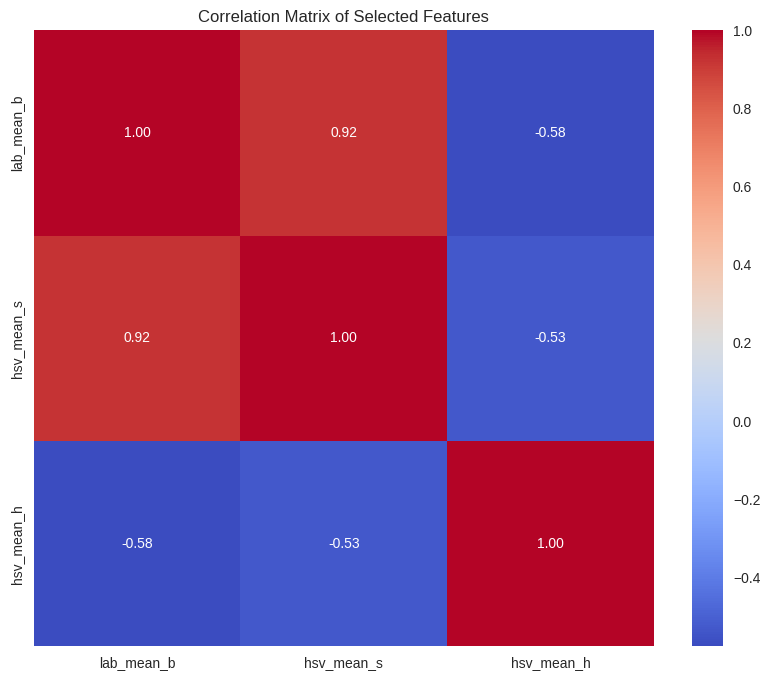

,feature,fisher_score
16,lab_mean_b,24.585212
14,lab_mean_a,17.405016
8,hsv_mean_s,16.713975
6,hsv_mean_h,8.640626
7,hsv_std_h,6.277974
0,mean_r,5.323356
10,hsv_mean_v,4.989767
13,lab_std_l,4.337721
11,hsv_std_v,4.328683
3,std_g,3.988759


In [25]:
if selected_features:
    plt.figure(figsize=(10, 8))
    sub_corr = corr_matrix.loc[selected_features, selected_features]
    if not sub_corr.empty:
        sns.heatmap(sub_corr, annot=True, fmt='.2f', cmap='coolwarm')
        plt.title('Correlation Matrix of Selected Features')
        plt.show()
    else:
        print('Correlation matrix empty; skipping heatmap.')
else:
    print('No selected features available to plot correlation heatmap.')

fisher_df.sort_values('fisher_score', ascending=False).head(10)



## Phase 3 – Clustering & Hyperparameter Tuning

In [ ]:
train_selected = train_features[selected_features].copy()
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_selected)
true_labels = train_features['class_name'].values
target_ms_clusters = len(np.unique(true_labels))

pca_components = min(10, train_scaled.shape[1])
pca_model = PCA(n_components=pca_components, random_state=RANDOM_STATE)
train_pca = pca_model.fit_transform(train_scaled)
representations = {
    'scaled': train_scaled,
    f'pca_{pca_components}': train_pca,
}

clustering_results = {}
tuning_history = {}

DBSCAN_MIN_SAMPLES = [3, 5, 8, 12]
dbscan_kdist = {}
for rep_name, data in representations.items():
    n_samples = len(data)
    for min_samples in DBSCAN_MIN_SAMPLES:
        k = min(max(min_samples, 2), n_samples - 1)
        if k < 1:
            continue
        nbrs = NearestNeighbors(n_neighbors=k)
        nbrs.fit(data)
        distances, _ = nbrs.kneighbors(data)
        kth = np.sort(distances[:, k - 1])
        dbscan_kdist[(rep_name, min_samples)] = kth

MS_QUANTILES = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4]
meanshift_inputs = {}
meanshift_bandwidths = {}
for rep_name, data in representations.items():
    scaled_for_ms = StandardScaler().fit_transform(data)
    if scaled_for_ms.shape[1] > 6:
        reducer = PCA(n_components=min(6, scaled_for_ms.shape[1]), whiten=True, random_state=RANDOM_STATE)
        reduced = reducer.fit_transform(scaled_for_ms)
    else:
        reduced = scaled_for_ms
    meanshift_inputs[rep_name] = reduced
    row_norms = np.linalg.norm(reduced, axis=1)
    median_radius = float(np.median(row_norms)) if len(row_norms) else 1.0
    for q in MS_QUANTILES:
        bw = estimate_bandwidth(reduced, quantile=q, n_samples=min(800, len(reduced)))
        if not np.isfinite(bw) or bw <= 0:
            bw = max(median_radius, 1.0)
        meanshift_bandwidths[(rep_name, q)] = bw


def normalize_params(params: dict) -> dict:
    cleaned = {}
    for key, value in params.items():
        if isinstance(value, np.generic):
            cleaned[key] = value.item()
        else:
            cleaned[key] = value
    return cleaned


def silhouette_safe(data: np.ndarray, labels: np.ndarray) -> float:
    labels = np.asarray(labels)
    unique = np.unique(labels)
    if len(unique) < 2 or len(data) <= len(unique):
        return -np.inf
    return silhouette_score(data, labels)


def enforce_min_cluster_size(data: np.ndarray, labels: np.ndarray, centers: np.ndarray, min_size: int) -> np.ndarray:
    labels = np.asarray(labels).copy()
    unique, counts = np.unique(labels, return_counts=True)
    if len(unique) == 0:
        return labels
    valid = [int(lbl) for lbl, cnt in zip(unique, counts) if cnt >= min_size]
    if len(valid) == len(unique) or len(valid) == 0:
        if len(valid) == 0:
            majority = int(unique[np.argmax(counts)])
            labels[:] = majority
        return labels
    valid = np.array(valid)
    valid_centers = np.array([centers[v] for v in valid])
    for lbl in unique:
        if lbl in valid:
            continue
        mask = labels == lbl
        if not np.any(mask):
            continue
        pts = data[mask]
        distances = np.linalg.norm(pts[:, None, :] - valid_centers[None, :, :], axis=2)
        nearest = valid[np.argmin(distances, axis=1)]
        labels[np.where(mask)[0]] = nearest
    return labels


def merge_excess_clusters(data: np.ndarray, labels: np.ndarray, target: int, percentile: float | None) -> np.ndarray:
    if target < 2 or percentile is None:
        return labels
    labels = np.asarray(labels).copy()
    unique = np.unique(labels)
    if len(unique) <= target:
        return labels
    def compute_centers(lbls):
        centers = {}
        weights = {}
        uniq = np.unique(lbls)
        for lbl in uniq:
            pts = data[lbls == lbl]
            if len(pts) == 0:
                continue
            centers[int(lbl)] = pts.mean(axis=0)
            weights[int(lbl)] = len(pts)
        return centers, weights
    centers, weights = compute_centers(labels)
    while len(centers) > target:
        keys = list(centers.keys())
        if len(keys) < 2:
            break
        dists = []
        for i in range(len(keys)):
            for j in range(i + 1, len(keys)):
                dist = np.linalg.norm(centers[keys[i]] - centers[keys[j]])
                dists.append((dist, keys[i], keys[j]))
        if not dists:
            break
        threshold = np.percentile([d for d, _, _ in dists], percentile)
        dists.sort(key=lambda x: x[0])
        min_dist, a, b = dists[0]
        if min_dist > threshold:
            break
        winner, loser = (a, b) if weights[a] >= weights[b] else (b, a)
        mask = labels == loser
        labels[mask] = winner
        total = weights[winner] + weights[loser]
        centers[winner] = (centers[winner] * weights[winner] + centers[loser] * weights[loser]) / total
        weights[winner] = total
        centers.pop(loser, None)
        weights.pop(loser, None)
    unique = np.unique(labels)
    mapping = {old: idx for idx, old in enumerate(unique)}
    labels = np.array([mapping[int(lbl)] for lbl in labels])
    return labels


def run_search(name: str, grid: dict, builder):
    best = {'score': -np.inf, 'model': None, 'labels': None, 'params': None, 'representation': None}
    history_rows = []
    for rep_name, data in representations.items():
        for params in ParameterGrid(grid):
            params = normalize_params(params)
            try:
                builder_output = builder(params.copy(), data, rep_name)
            except Exception as exc:
                history_rows.append({
                    'representation': rep_name,
                    'params': json.dumps(params),
                    'silhouette': np.nan,
                    'n_clusters': np.nan,
                    'status': f'error: {exc}'
                })
                continue
            score_data = data
            if isinstance(builder_output, tuple):
                if len(builder_output) == 4:
                    model, labels, effective_params, score_data = builder_output
                elif len(builder_output) == 3:
                    model, labels, effective_params = builder_output
                else:
                    model, labels = builder_output
                    effective_params = params
            else:
                model, labels = builder_output
                effective_params = params
            effective_params = normalize_params(effective_params)
            unique = len(np.unique(labels))
            score = silhouette_safe(score_data, labels)
            history_rows.append({
                'representation': rep_name,
                'params': json.dumps(effective_params),
                'silhouette': score,
                'n_clusters': unique,
                'status': 'ok'
            })
            if score > best['score']:
                best = {
                    'score': score,
                    'model': model,
                    'labels': labels,
                    'params': effective_params,
                    'representation': rep_name
                }
    tuning_history[name] = pd.DataFrame(history_rows).sort_values('silhouette', ascending=False)
    clustering_results[name] = best
    if best['params'] is None:
        print(f'{name}: no valid configuration discovered.')
    else:
        print(f'Best {name} ({best["representation"]} space):', best['params'], 'silhouette=', round(best['score'], 4))


# KMeans search across wider grid
kmeans_grid = {
    'n_clusters': [9],
    'init': ['k-means++', 'random'],
    'n_init': [25, 40],
    'max_iter': [300, 500]
}


def build_kmeans(params, data, rep_name):
    model = KMeans(**params, random_state=RANDOM_STATE)
    labels = model.fit_predict(data)
    return model, labels


run_search('KMeans', kmeans_grid, build_kmeans)

# Agglomerative search with diverse linkages/metrics
agg_grid = {
    'n_clusters': [9],
    'linkage': ['ward', 'average', 'complete'],
    'metric': ['euclidean', 'manhattan']
}


def build_agg(params, data, rep_name):
    params = params.copy()
    metric = params.pop('metric')
    if params['linkage'] == 'ward' and metric != 'euclidean':
        raise ValueError('Ward linkage requires euclidean metric')
    model = AgglomerativeClustering(**params, metric=metric)
    labels = model.fit_predict(data)
    return model, labels


run_search('Agglomerative', agg_grid, build_agg)

# DBSCAN search with adaptive k-distance eps
dbscan_grid = {
    'min_samples': DBSCAN_MIN_SAMPLES,
    'quantile': [0.7, 0.75, 0.8, 0.85, 0.9, 0.95],
    'eps_scale': [0.85, 0.95, 1.05, 1.15],
    'leaf_size': [30, 50]
}


def build_dbscan(params, data, rep_name):
    key = (rep_name, params['min_samples'])
    kth = dbscan_kdist.get(key)
    if kth is None or len(kth) == 0:
        raise ValueError('Insufficient k-distance data for DBSCAN')
    eps = np.quantile(kth, params['quantile']) * params['eps_scale']
    eps = max(float(eps), 1e-3)
    model = DBSCAN(eps=eps, min_samples=params['min_samples'], leaf_size=params['leaf_size'])
    labels = model.fit_predict(data)
    effective = {
        'eps': float(eps),
        'min_samples': params['min_samples'],
        'leaf_size': params['leaf_size'],
        'quantile': params['quantile'],
        'eps_scale': params['eps_scale']
    }
    return model, labels, effective


run_search('DBSCAN', dbscan_grid, build_dbscan)

# MeanShift search on reduced PCA space
meanshift_grid = {
    'quantile': MS_QUANTILES,
    'bandwidth_multiplier': [0.4, 0.6, 0.8, 1.0, 1.3, 1.6, 2.0],
    'bin_seeding': [True, False],
    'min_cluster_size': [5, 8, 12],
    'merge_percentile': [20, 35, 50, None]
}


def build_meanshift(params, data, rep_name):
    ms_data = meanshift_inputs[rep_name]
    base = meanshift_bandwidths.get((rep_name, params['quantile']), 1.0)
    bandwidth = max(1e-3, base * params['bandwidth_multiplier'])
    model = MeanShift(bandwidth=bandwidth, bin_seeding=params['bin_seeding'])
    labels = model.fit_predict(ms_data)
    labels = enforce_min_cluster_size(ms_data, labels, model.cluster_centers_, params['min_cluster_size'])
    labels = merge_excess_clusters(ms_data, labels, target_ms_clusters, params.get('merge_percentile'))
    unique_labels = np.unique(labels)
    new_centers = []
    for lbl in unique_labels:
        cluster_points = ms_data[labels == lbl]
        new_centers.append(cluster_points.mean(axis=0))
    model.cluster_centers_ = np.array(new_centers)
    remap = {old: idx for idx, old in enumerate(unique_labels)}
    labels = np.array([remap[int(lbl)] for lbl in labels])
    effective = {
        'bandwidth': float(bandwidth),
        'quantile': params['quantile'],
        'bandwidth_multiplier': params['bandwidth_multiplier'],
        'bin_seeding': params['bin_seeding'],
        'min_cluster_size': params['min_cluster_size'],
        'merge_percentile': params.get('merge_percentile')
    }
    return model, labels, effective, ms_data


run_search('MeanShift', meanshift_grid, build_meanshift)




Best KMeans (scaled space): {'init': 'random', 'max_iter': 300, 'n_clusters': 9, 'n_init': 25} silhouette= 0.5914
Best Agglomerative (pca_3 space): {'linkage': 'complete', 'metric': 'manhattan', 'n_clusters': 9} silhouette= 0.5969
Best DBSCAN (scaled space): {'eps': 0.1953318665474665, 'min_samples': 3, 'leaf_size': 30, 'quantile': 0.95, 'eps_scale': 1.15} silhouette= 0.5893
Best MeanShift (scaled space): {'bandwidth': 0.6173038515187779, 'quantile': 0.4, 'bandwidth_multiplier': 0.4, 'bin_seeding': True, 'min_cluster_size': 5, 'merge_percentile': 20} silhouette= 0.6216


In [27]:
for name, history in tuning_history.items():
    if history.empty:
        print(f'No successful runs recorded for {name}.')
        continue
    print(f'Top configurations for {name}:')
    display(history.head(5))


Top configurations for KMeans:


,representation,params,silhouette,n_clusters,status
7,scaled,"{""init"": ""random"", ""max_iter"": 500, ""n_cluster...",0.591361,9,ok
6,scaled,"{""init"": ""random"", ""max_iter"": 500, ""n_cluster...",0.591361,9,ok
5,scaled,"{""init"": ""random"", ""max_iter"": 300, ""n_cluster...",0.591361,9,ok
4,scaled,"{""init"": ""random"", ""max_iter"": 300, ""n_cluster...",0.591361,9,ok
12,pca_3,"{""init"": ""random"", ""max_iter"": 300, ""n_cluster...",0.591361,9,ok


Top configurations for Agglomerative:


,representation,params,silhouette,n_clusters,status
11,pca_3,"{""linkage"": ""complete"", ""metric"": ""manhattan"",...",0.596950,9.0,ok
6,pca_3,"{""linkage"": ""ward"", ""metric"": ""euclidean"", ""n_...",0.592542,9.0,ok
0,scaled,"{""linkage"": ""ward"", ""metric"": ""euclidean"", ""n_...",0.592542,9.0,ok
10,pca_3,"{""linkage"": ""complete"", ""metric"": ""euclidean"",...",0.540102,9.0,ok
4,scaled,"{""linkage"": ""complete"", ""metric"": ""euclidean"",...",0.540102,9.0,ok


Top configurations for DBSCAN:


,representation,params,silhouette,n_clusters,status
173,scaled,"{""eps"": 0.1953318665474665, ""min_samples"": 3, ...",0.589252,8,ok
149,scaled,"{""eps"": 0.1953318665474665, ""min_samples"": 3, ...",0.589252,8,ok
365,pca_3,"{""eps"": 0.19533186654746681, ""min_samples"": 3,...",0.589252,8,ok
341,pca_3,"{""eps"": 0.19533186654746681, ""min_samples"": 3,...",0.589252,8,ok
125,scaled,"{""eps"": 0.17834648684768684, ""min_samples"": 3,...",0.558860,9,ok


Top configurations for MeanShift:


,representation,params,silhouette,n_clusters,status
7,scaled,"{""bandwidth"": 0.6173038515187779, ""quantile"": ...",0.621611,6,ok
55,scaled,"{""bandwidth"": 0.6173038515187779, ""quantile"": ...",0.621611,6,ok
31,scaled,"{""bandwidth"": 0.6173038515187779, ""quantile"": ...",0.621611,6,ok
103,scaled,"{""bandwidth"": 0.6173038515187779, ""quantile"": ...",0.621611,6,ok
195,scaled,"{""bandwidth"": 0.5935049723035176, ""quantile"": ...",0.621611,6,ok


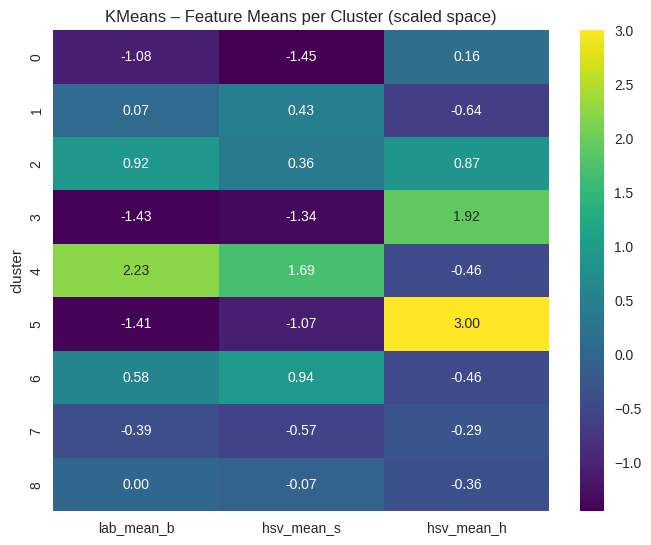

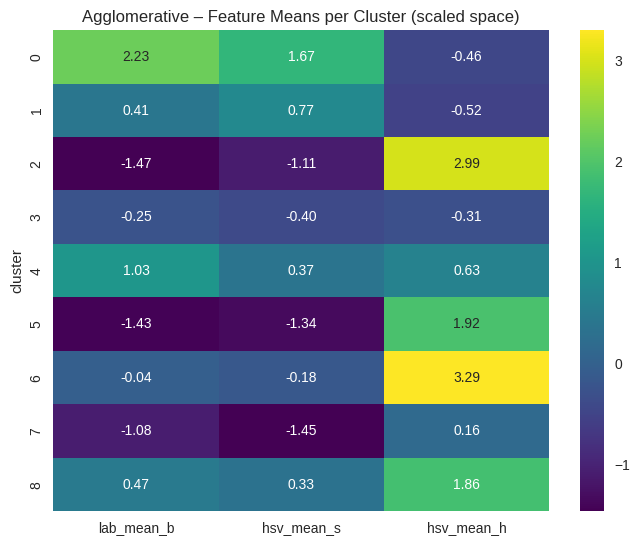

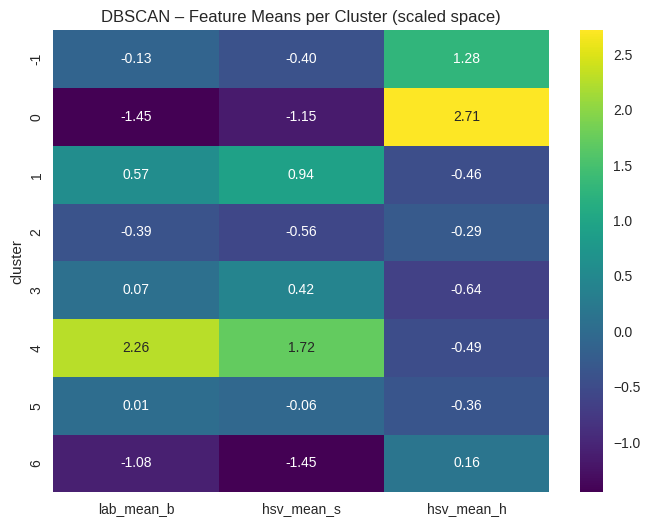

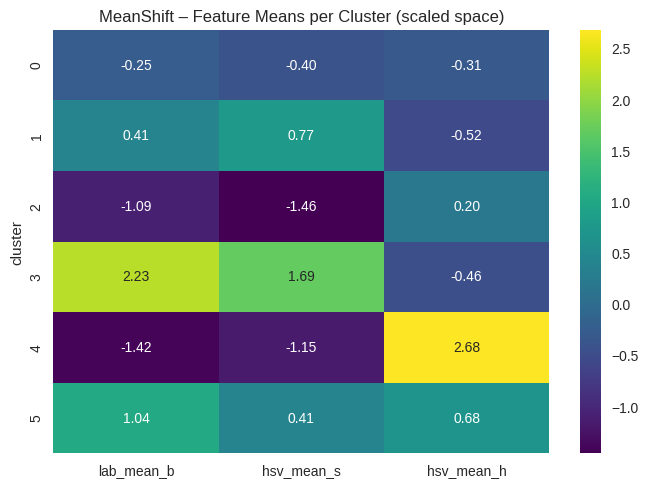

In [28]:
cluster_feature_df = pd.DataFrame(train_scaled, columns=selected_features)

def plot_cluster_heatmap(name: str, labels: np.ndarray):
    df = cluster_feature_df.copy()
    df['cluster'] = labels
    summary = df.groupby('cluster')[selected_features].mean().sort_index()
    plt.figure(figsize=(8, 4 + 0.25 * len(summary)))
    sns.heatmap(summary, cmap='viridis', annot=True, fmt='.2f')
    plt.title(f'{name} – Feature Means per Cluster (scaled space)')
    plt.show()

for algo_name, result in clustering_results.items():
    if result['score'] == -np.inf:
        print(f'Skipping heatmap for {algo_name} (no valid clustering).')
        continue
    plot_cluster_heatmap(algo_name, result['labels'])


## Phase 4 – Dimensionality Reduction & Visualization
PCA projects the standardized feature space into 2D so we can visually inspect cluster separation for each algorithm.


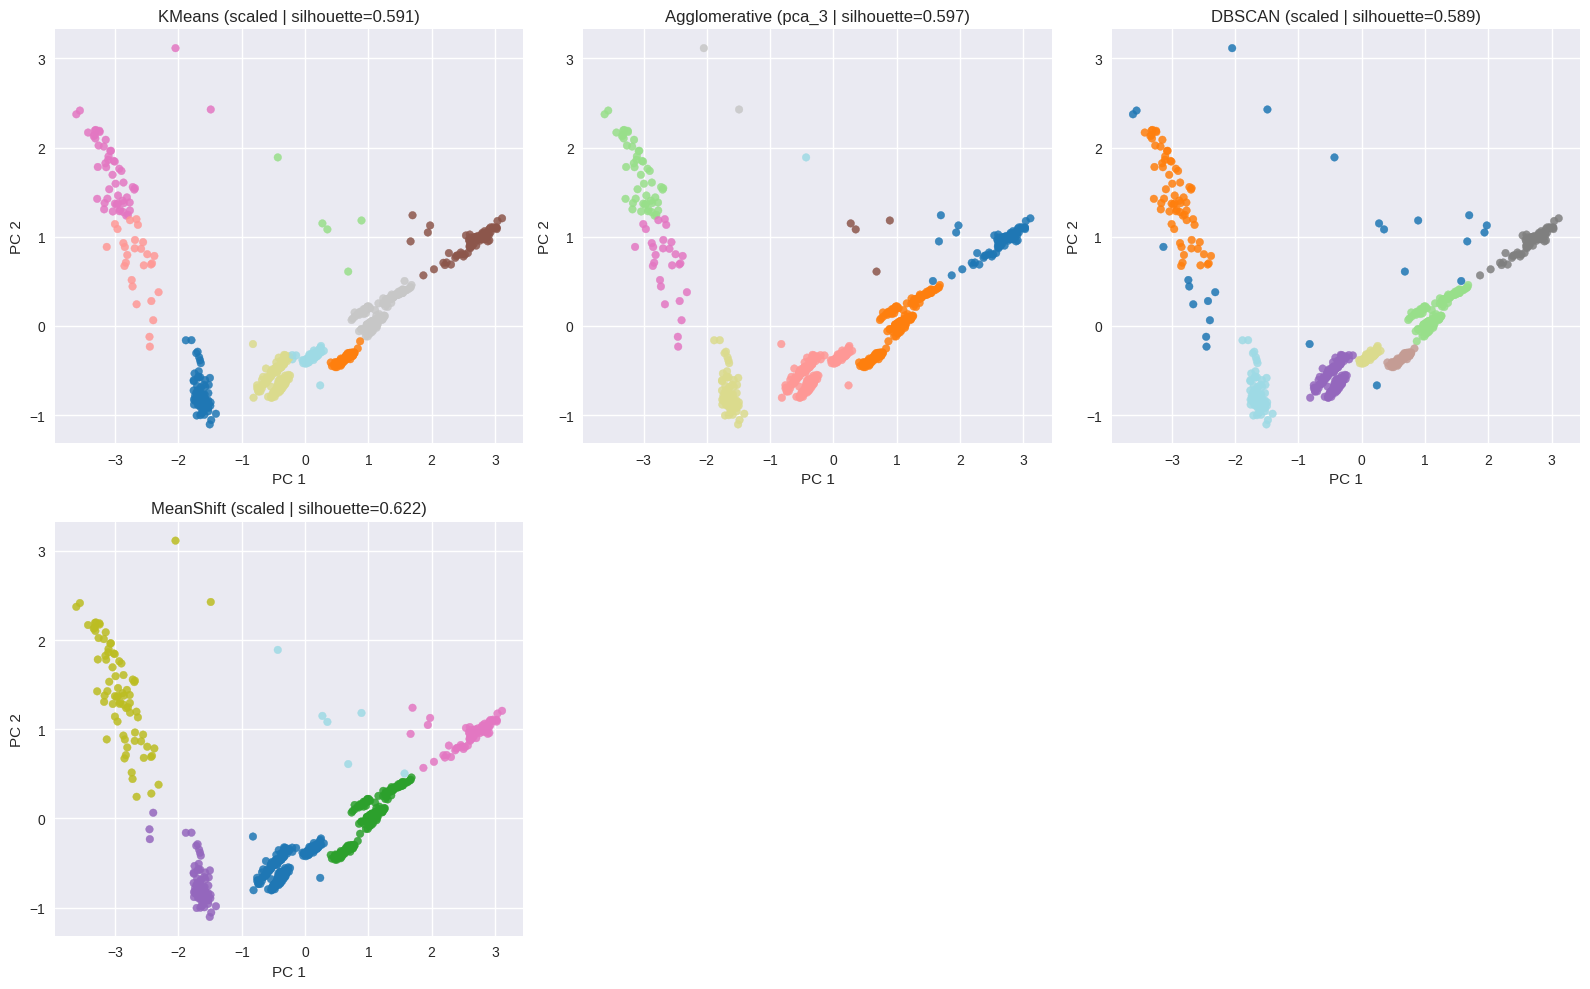

In [29]:
if train_pca.shape[1] >= 2:
    embedding = train_pca[:, :2]
else:
    pca_vis = PCA(n_components=2, random_state=RANDOM_STATE)
    embedding = pca_vis.fit_transform(train_scaled)
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
for ax, (name, result) in zip(axes, clustering_results.items()):
    labels = result['labels']
    if result['params'] is None or result['score'] == -np.inf:
        ax.set_axis_off()
        ax.set_title(f'{name}: unavailable')
        continue
    scatter = ax.scatter(embedding[:, 0], embedding[:, 1], c=labels, cmap='tab20', s=30, alpha=0.85)
    ax.set_title(f"{name} ({result['representation']} | silhouette={result['score']:.3f})")
    ax.set_xlabel('PC 1')
    ax.set_ylabel('PC 2')
for extra_ax in axes[len(clustering_results):]:
    extra_ax.set_axis_off()
fig.tight_layout()
plt.show()



## Phase 5 – Evaluation
We implement the Rand Index manually as requested, and also report Silhouette Score (cohesion/separation) plus Adjusted Rand Index (chance-corrected agreement). Differences between the metrics are discussed below.


In [30]:
from math import comb

def rand_index(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    n = len(y_true)
    if n < 2:
        return 1.0
    contingency = pd.crosstab(y_true, y_pred)
    agree_same = 0
    for value in contingency.to_numpy().ravel():
        if value >= 2:
            agree_same += comb(int(value), 2)
    true_pairs = sum(comb(int(count), 2) for count in contingency.sum(axis=1))
    pred_pairs = sum(comb(int(count), 2) for count in contingency.sum(axis=0))
    total_pairs = comb(n, 2)
    agree_diff = total_pairs - true_pairs - pred_pairs + agree_same
    return (agree_same + agree_diff) / total_pairs

metrics_rows = []
for name, result in clustering_results.items():
    labels = result['labels']
    if result['params'] is None or result['score'] == -np.inf:
        continue
    rep_name = result.get('representation', 'scaled')
    data = representations.get(rep_name, train_scaled)
    silhouette = silhouette_score(data, labels) if len(np.unique(labels)) > 1 else np.nan
    ri = rand_index(true_labels, labels)
    ari = adjusted_rand_score(true_labels, labels)
    metrics_rows.append({
        'algorithm': name,
        'representation': rep_name,
        'silhouette_score': silhouette,
        'rand_index': ri,
        'adjusted_rand_index': ari,
        'params': json.dumps(result['params'])
    })

eval_df = pd.DataFrame(metrics_rows).sort_values('silhouette_score', ascending=False)
print(eval_df)
eval_df.to_csv(EVAL_RESULTS_PATH, index=False)
print(f'Saved evaluation metrics to {EVAL_RESULTS_PATH.name}')



       algorithm representation  silhouette_score  rand_index  \
3      MeanShift         scaled          0.621611    0.846211   
1  Agglomerative          pca_3          0.596950    0.843244   
0         KMeans         scaled          0.591361    0.939610   
2         DBSCAN         scaled          0.589252    0.943296   

   adjusted_rand_index                                             params  
3             0.503930  {"bandwidth": 0.6173038515187779, "quantile": ...  
1             0.486491  {"linkage": "complete", "metric": "manhattan",...  
0             0.734824  {"init": "random", "max_iter": 300, "n_cluster...  
2             0.752523  {"eps": 0.1953318665474665, "min_samples": 3, ...  
Saved evaluation metrics to clustering_evaluation.csv


Silhouette primarily captures intra/inter-cluster geometry in feature space, whereas (Adjusted) Rand Index compares predicted clusters with the ground-truth material labels. Discrepancies indicate when compact clusters do not align with semantic classes (or vice versa). The manual RI and ARI help explain those trade-offs while Silhouette guides unsupervised tuning.


## Phase 6 – Prediction & Cluster-Based Retrieval
We reuse the tuned KMeans model to assign clusters to held-out test images. Each cluster adopts the majority-vote class label from training data. For qualitative analysis we also visualize, per test sample, two representative training images from the same predicted cluster.


In [31]:
kmeans_model = clustering_results['KMeans']['model']
train_cluster_labels = clustering_results['KMeans']['labels']

cluster_to_label = {}
train_df = train_features[['image_path', 'class_name']].copy()
train_df['cluster'] = train_cluster_labels
for cluster_id, group in train_df.groupby('cluster'):
    cluster_to_label[cluster_id] = group['class_name'].value_counts().idxmax()

selected_test = test_features[selected_features].copy()
if not selected_test.empty:
    test_scaled = scaler.transform(selected_test)
    test_clusters = kmeans_model.predict(test_scaled)
    test_predictions = test_features[['image_path', 'class_name']].copy()
    test_predictions['predicted_cluster'] = test_clusters
    test_predictions['predicted_label'] = test_predictions['predicted_cluster'].map(cluster_to_label)
    display(test_predictions.head())
else:
    test_predictions = pd.DataFrame()
    print('No test images found for prediction phase.')


,image_path,class_name,predicted_cluster,predicted_label
0,aluminium_foil/test/15-scale_1_im_1_col.png,aluminium_foil,3,aluminium_foil
1,aluminium_foil/test/15-scale_2_im_3_col.png,aluminium_foil,3,aluminium_foil
2,aluminium_foil/test/15-scale_3_im_6_col.png,aluminium_foil,3,aluminium_foil
3,brown_bread/test/48-scale_3_im_2_col.png,brown_bread,6,corduroy
4,brown_bread/test/48-scale_6_im_2_col.png,brown_bread,6,corduroy


In [32]:
if not selected_test.empty:
    test_representations = {'scaled': test_scaled}
    rep_key = f'pca_{pca_components}'
    if rep_key in representations:
        test_representations[rep_key] = pca_model.transform(test_scaled)
    accuracy_rows = []
    true_test_labels = test_features['class_name'].values

    def derive_meanshift_view(rep_name: str):
        base_train = representations.get(rep_name)
        base_test = test_representations.get(rep_name)
        if base_train is None or base_test is None:
            return None
        ms_scaler = StandardScaler().fit(base_train)
        train_ms = ms_scaler.transform(base_train)
        test_ms = ms_scaler.transform(base_test)
        if train_ms.shape[1] > 6:
            reducer = PCA(n_components=min(6, train_ms.shape[1]), whiten=True, random_state=RANDOM_STATE)
            train_ms = reducer.fit_transform(train_ms)
            test_ms = reducer.transform(test_ms)
        return test_ms, train_ms

    for name, result in clustering_results.items():
        if result.get('params') is None or result.get('score') == -np.inf:
            continue
        rep_name = result.get('representation', 'scaled')
        train_labels = np.asarray(result['labels'])
        if name == 'MeanShift':
            ms_view = derive_meanshift_view(rep_name)
            if ms_view is None:
                print(f'{name}: missing test representation for accuracy.')
                continue
            test_data, train_data = ms_view
        else:
            test_data = test_representations.get(rep_name)
            train_data = representations.get(rep_name)
        if test_data is None or train_data is None:
            print(f'{name}: missing data for test accuracy.')
            continue
        model = result['model']
        try:
            test_clusters = model.predict(test_data)
        except Exception:
            centers = []
            center_labels = []
            for lbl in np.unique(train_labels):
                mask = train_labels == lbl
                if mask.any():
                    centers.append(train_data[mask].mean(axis=0))
                    center_labels.append(lbl)
            if not centers:
                print(f'{name}: unable to derive cluster centers.')
                continue
            centers = np.vstack(centers)
            center_labels = np.array(center_labels)
            distances = np.linalg.norm(test_data[:, None, :] - centers[None, :, :], axis=2)
            test_clusters = center_labels[distances.argmin(axis=1)]
        train_df_local = train_features[['class_name']].copy()
        train_df_local['cluster'] = train_labels
        cluster_to_label_local = {
            cluster_id: grp['class_name'].value_counts().idxmax()
            for cluster_id, grp in train_df_local.groupby('cluster')
        }
        predicted_labels = np.array([cluster_to_label_local.get(lbl) for lbl in test_clusters])
        accuracy = float((predicted_labels == true_test_labels).mean()) if len(predicted_labels) else float('nan')
        accuracy_rows.append((name, accuracy))
    if accuracy_rows:
        for name, acc in accuracy_rows:
            print(f'{name} test accuracy: {acc:.4f}')
else:
    print('Skipping algorithm accuracy: no test images.')


KMeans test accuracy: 0.7778
Agglomerative test accuracy: 0.5556
DBSCAN test accuracy: 0.7407
MeanShift test accuracy: 0.5556


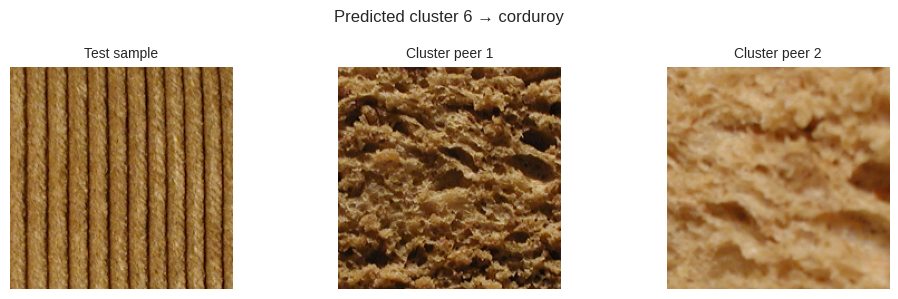

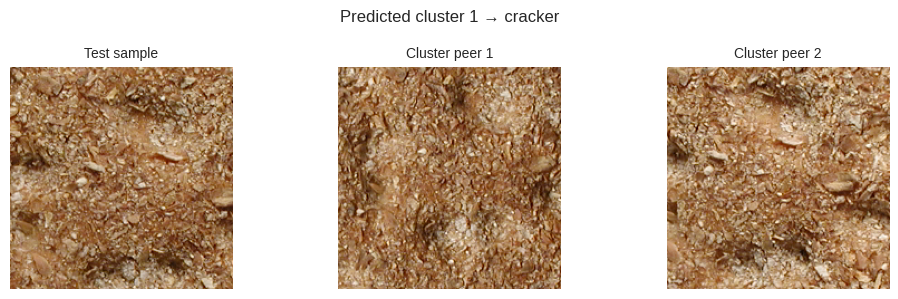

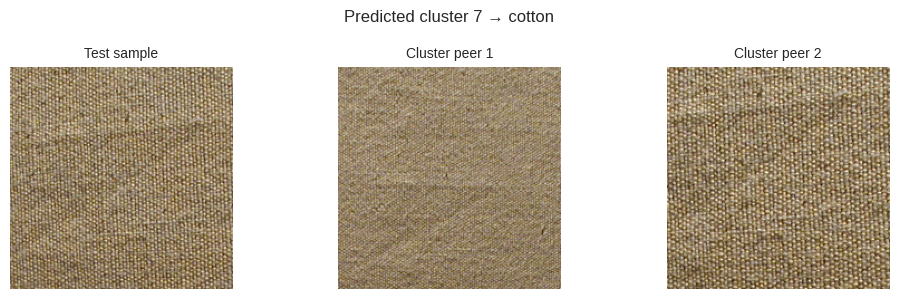

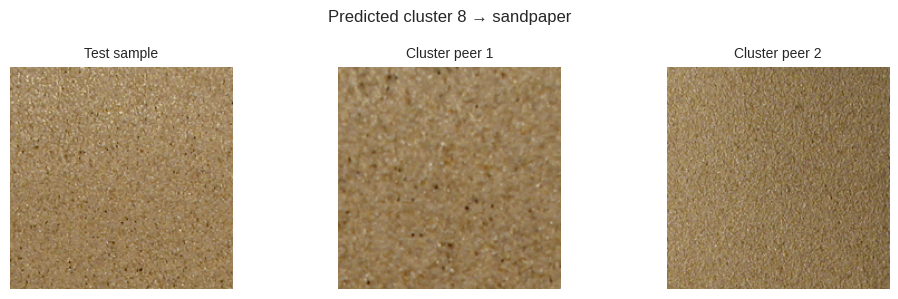

In [33]:
def show_test_examples(df: pd.DataFrame, samples: int = 4):
    if df.empty:
        print('No test predictions available for visualization.')
        return
    subset = df.sample(min(samples, len(df)), random_state=RANDOM_STATE)
    for _, row in subset.iterrows():
        cluster_id = row['predicted_cluster']
        cluster_paths = train_df[train_df['cluster'] == cluster_id]['image_path'].tolist()
        if len(cluster_paths) < 2:
            cluster_paths = (cluster_paths * 2)[:2]
        else:
            cluster_paths = random.sample(cluster_paths, 2)
        fig, axes = plt.subplots(1, 3, figsize=(10, 3))
        paths_to_show = [row['image_path']] + cluster_paths
        titles = ['Test sample', 'Cluster peer 1', 'Cluster peer 2']
        for ax, path, title in zip(axes, paths_to_show, titles):
            img = load_image(DATA_ROOT / path)
            ax.imshow(img)
            ax.axis('off')
            ax.set_title(title, fontsize=10)
        fig.suptitle(f'Predicted cluster {cluster_id} → {cluster_to_label.get(cluster_id)}', fontsize=12)
        plt.tight_layout()
        plt.show()

show_test_examples(test_predictions, samples=4)
